In [5]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from IPython.display import Image, display
import os

load_dotenv()
API_KEY = os.getenv("SILICON_API_KEY")
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key=API_KEY,
    temperature=0.0
)


def display_graph(app):
    # 使用 Graphviz 渲染（Colab 最稳定的方案）
    try:
        display(Image(app.get_graph(xray=True).draw_png()))
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print(app.get_graph(xray=True).draw_mermaid())

In [6]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    score: float
    decision: str


def evaluate(state: State) -> dict:
    score = state["score"]
    """评估并打分"""
    return {"score": score}


def route_by_score(state: State) -> Literal["high", "medium", "low"]:
    """根据分数路由"""
    score = state["score"]
    if score > 0.8:
        return "high"
    elif score > 0.5:
        return "medium"
    else:
        return "low"


def handle_high(state: State) -> dict:
    return {"decision": "自动通过"}


def handle_medium(state: State) -> dict:
    return {"decision": "人工审核"}


def handle_low(state: State) -> dict:
    return {"decision": "自动拒绝"}

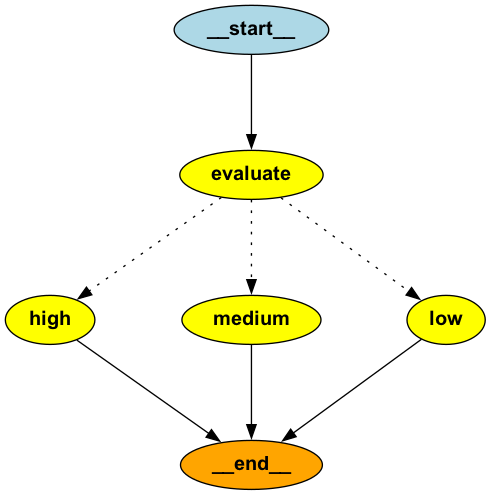

In [7]:
# 构建图
graph = StateGraph(State)
graph.add_node("evaluate", evaluate)
graph.add_node("high", handle_high)
graph.add_node("medium", handle_medium)
graph.add_node("low", handle_low)

graph.add_edge(START, "evaluate")
graph.add_conditional_edges(
    "evaluate",
    route_by_score,
    {
        "high": "high",
        "medium": "medium",
        "low": "low"
    }
)

for node in ["high", "medium", "low"]:
    graph.add_edge(node, END)

app = graph.compile()
display_graph(app)

In [9]:
result = app.invoke({"score":0.9})
print(result["decision"])


自动通过
